In [5]:
from google.colab import files
uploaded = files.upload()


Saving archive (2).zip to archive (2).zip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [7]:
import zipfile
import os

zip_path = "archive (2).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")

print(os.listdir("data"))

['student_dropout_dataset.csv']


In [8]:
import pandas as pd

df = pd.read_csv("data/student_dropout_dataset.csv")
df.head()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0.1064,0,0,active
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,0.6627,1,2,dropped
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,0.7299,1,2,dropped
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,0.5315,1,1,at-risk
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,0.7904,1,2,dropped


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   region                  5000 non-null   object 
 3   enroll_date             5000 non-null   object 
 4   exam_season             5000 non-null   int64  
 5   courses_enrolled        5000 non-null   int64  
 6   completed_assignments   5000 non-null   int64  
 7   completion_rate         5000 non-null   float64
 8   login_frequency         5000 non-null   float64
 9   last_activity_days_ago  5000 non-null   int64  
 10  forum_posts_count       5000 non-null   int64  
 11  dropout_score           5000 non-null   float64
 12  label                   5000 non-null   int64  
 13  label_multiclass        5000 non-null   int64  
 14  label_name              5000 non-null   

In [36]:
df.describe()

,age,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_encoded,engagement_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,23.736600,0.094000,3.999400,5.188400,0.260985,3.453820,9.3564,4.212200,0.431556,0.659200,0.985800,0.985800,-0.704641
std,4.583211,0.291858,1.997348,6.109466,0.249010,3.248316,9.4361,4.270131,0.263529,0.474026,0.816904,0.816904,2.171839
min,17.000000,0.000000,1.000000,0.000000,0.000000,0.100000,1.0000,0.000000,0.000000,0.000000,0.000000,0.000000,-12.898950
25%,20.000000,0.000000,2.000000,1.000000,0.053900,0.980000,2.0000,1.000000,0.204575,0.000000,0.000000,0.000000,-1.661150
50%,24.000000,0.000000,4.000000,3.000000,0.206700,2.440000,6.0000,3.000000,0.441550,1.000000,1.000000,1.000000,-0.346650
75%,27.000000,0.000000,6.000000,7.000000,0.389025,4.942500,13.0000,6.000000,0.658325,1.000000,2.000000,2.000000,0.531375
max,40.000000,1.000000,7.000000,35.000000,1.000000,14.000000,70.0000,24.000000,1.000000,1.000000,2.000000,2.000000,4.500000


In [37]:
df.columns

Index(['student_id', 'age', 'region', 'enroll_date', 'exam_season',
       'courses_enrolled', 'completed_assignments', 'completion_rate',
       'login_frequency', 'last_activity_days_ago', 'forum_posts_count',
       'dropout_score', 'label', 'label_multiclass', 'label_name',
       'label_encoded', 'engagement_score'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
student_id,0
age,0
region,0
enroll_date,0
exam_season,0
courses_enrolled,0
completed_assignments,0
completion_rate,0
login_frequency,0
last_activity_days_ago,0


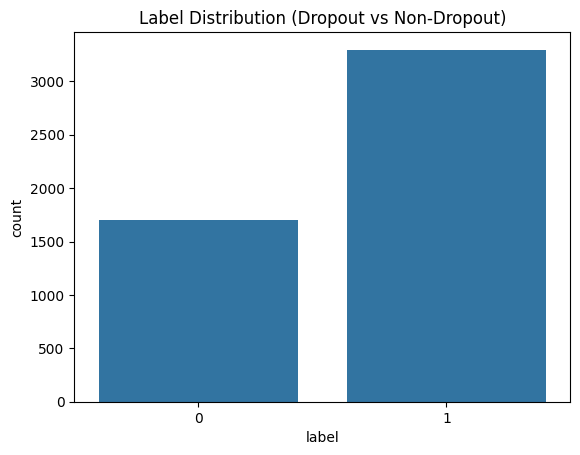

In [9]:
# count plot of labels
sns.countplot(x=df["label"])
plt.title("Label Distribution (Dropout vs Non-Dropout)")
plt.show()

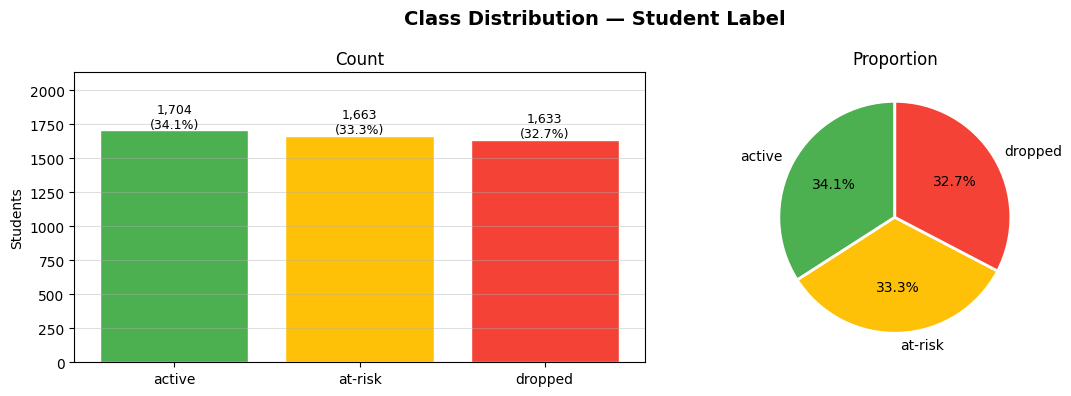

In [10]:
import matplotlib.pyplot as plt

COLORS = ["#4CAF50", "#FFC107", "#F44336"]  # green, yellow, red

vc = df["label_name"].value_counts().reindex(["active", "at-risk", "dropped"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Class Distribution — Student Label", fontsize=14, fontweight="bold")

# ----- Bar Chart -----
bars = axes[0].bar(vc.index, vc.values, color=COLORS, edgecolor="white")

for bar, val in zip(bars, vc.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f"{val:,}\n({val/len(df)*100:.1f}%)",
        ha="center",
        fontsize=9
    )

axes[0].set_title("Count")
axes[0].set_ylabel("Students")
axes[0].grid(axis="y", alpha=0.4)
axes[0].set_ylim(0, vc.max() * 1.25)

# ----- Pie Chart -----
axes[1].pie(
    vc.values,
    labels=vc.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=COLORS,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

axes[1].set_title("Proportion")

plt.tight_layout()
plt.show()

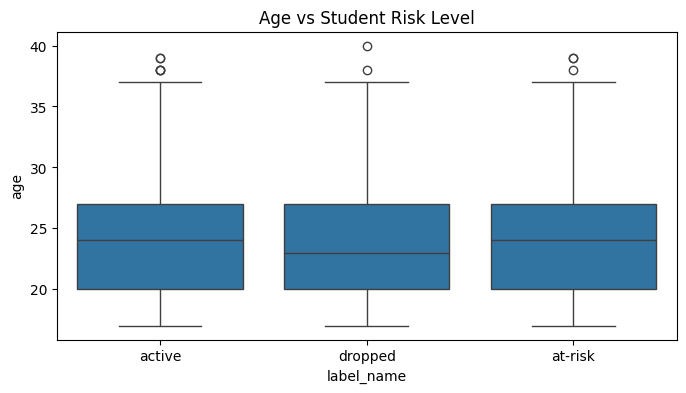

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(x="label_name", y="age", data=df)
plt.title("Age vs Student Risk Level")
plt.show()

In [38]:
df["engagement_score"] = (
    df["completion_rate"] * 0.5 +
    df["login_frequency"] * 0.3 -
    df["last_activity_days_ago"] * 0.2
)

In [39]:
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label_name"])


In [ ]:
features = [
    "completion_rate",
    "login_frequency",
    "last_activity_days_ago",
    "completed_assignments",
    "courses_enrolled",
    "engagement_score"
]
X = df[features]
y = df["label_encoded"]



In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)



In [42]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [43]:
y_pred = model.predict(X_test)

In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.839

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.82      0.86       333
           1       0.74      0.78      0.76       327
           2       0.88      0.91      0.89       340

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000



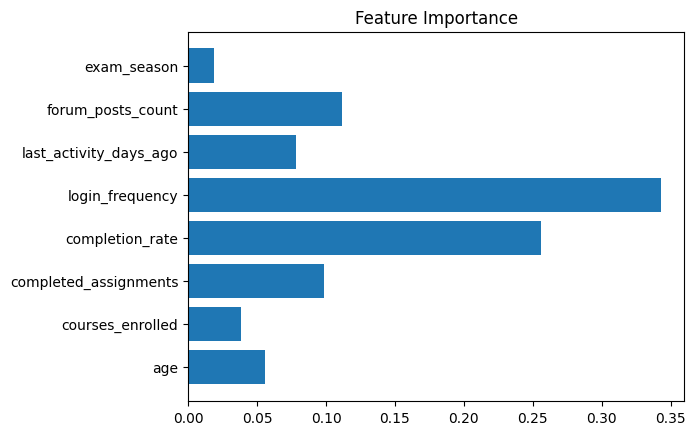

In [31]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

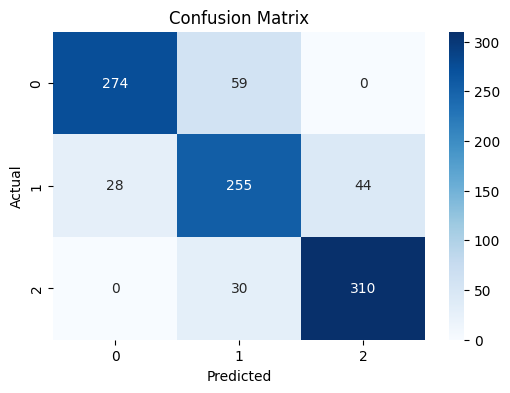

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [50]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.851
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       333
           1       0.77      0.78      0.77       327
           2       0.87      0.92      0.90       340

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000



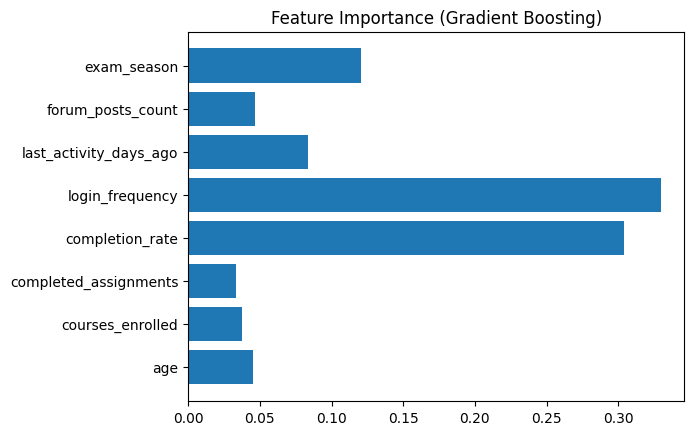

In [49]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.barh(X.columns, importances)
plt.title("Feature Importance (Gradient Boosting)")
plt.show()

In [51]:
results = {
    "RandomForest": 0.83,
    "GradientBoosting": 0.85
}

print(results)

{'RandomForest': 0.83, 'GradientBoosting': 0.85}
